### Chapter 10: Fancy Indexing

**10.1 Exploring Fancy Indexing**

* Basic concepts

In [3]:
import numpy as np

rng = np.random.default_rng(seed=1701)
x = rng.integers(100, size=10)
print(x)

# General method
print([x[3], x[7], x[2]])

# Fancy Indexing
ind = [3, 7, 4]
print([x[ind]])

[90 40  9 30 80 67 39 15 33 79]
[np.int64(30), np.int64(15), np.int64(9)]
[array([30, 15, 80])]


* The shape of the index array determines the shape of the result.

In [4]:
ind = np.array([[3, 7], [4, 5]])
print([x[ind]])

[array([[30, 15],
       [80, 67]])]


* In 2D array fancy indexing

In [ ]:
X = np.arange(12).reshape((3, 4))
print(X)

row = np.array([0, 1, 2])
col = np.array([2, 1 ,3])

print(X[row, col])  # [2 5 11] → X[0,2], X[1,1], X[2,3]

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[ 2  5 11]


* Used with broadcasting

In [7]:
# column vector와 row vector 결합
print(X[row[:, np.newaxis], col])

[[ 2  1  3]
 [ 6  5  7]
 [10  9 11]]


**10.2 Combined Indexing**

Fancy indexing은 다른 인덱싱 방식과 결합 가능

In [7]:
import numpy as np

X = np.arange(12).reshape((3, 4))
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

# Fancy + simple index
print(X[2, [2, 0, 1]])

# Fancy + slicing
print(X[1:, [2, 0, 1]])

# Fancy + masking
row = np.array([0, 1, 2])
mask = np.array([True, False, True, False])

print(X[row[:, np.newaxis], mask])

[10  8  9]
[[ 6  4  5]
 [10  8  9]]
[[ 0  2]
 [ 4  6]
 [ 8 10]]


**10.3 Example: Selecting Random Points**

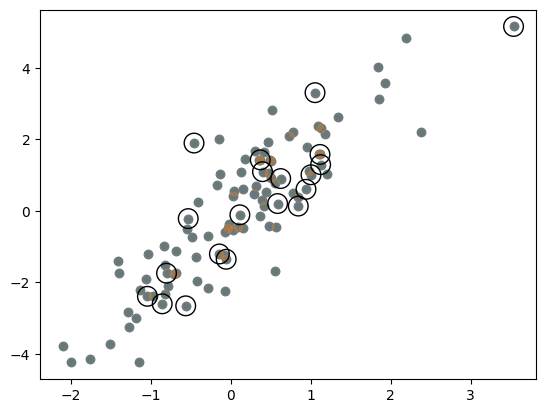

In [16]:
import matplotlib.pyplot as plt

# 2D 정규분포에서 100 points creation
mean = [0, 0]
cov = [[1, 2], [2, 5]]
X = rng.multivariate_normal(mean, cov, 100)

# Visualization
plt.scatter(X[:, 0], X[:, 1]);

# random 20 points seletion (no replace)
indices = np.random.choice(X.shape[0], 20, replace=False)
selection = X[indices]

# selected points 강조 표시
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
plt.scatter(selection[:, 0], selection[:, 1], 
            facecolor='none', edgecolor='black', s=200);

**10.4 Modifying Values with Fancy Indexing**

In [18]:
x = np.arange(10)
i = np.array([2, 1, 8, 4])
x[i] = 99
print(x)

x[i] -= 10
print(x)

[ 0 99 99  3 99  5  6  7 99  9]
[ 0 89 89  3 89  5  6  7 89  9]


⚠️ Beware of duplicate indexes!

In [25]:
x = np.zeros(10)
x[[0, 0]] = [4, 6]
print(x[0])     # 6 (마지막 값만 적용!)

i = [2, 3, 3, 4, 4, 4]
x = np.zeros(10)
x[i] += 1
print(x)    # [0. 0. 1. 1. 1. 0. ...] (한 번만 적용됨)

# 중복 인덱스에 여러 번 적용하려면?
np.add.at(x, i, 1)
print(x)

6.0
[0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
[0. 0. 2. 3. 4. 0. 0. 0. 0. 0.]


**10.5 Example: Binning Data**

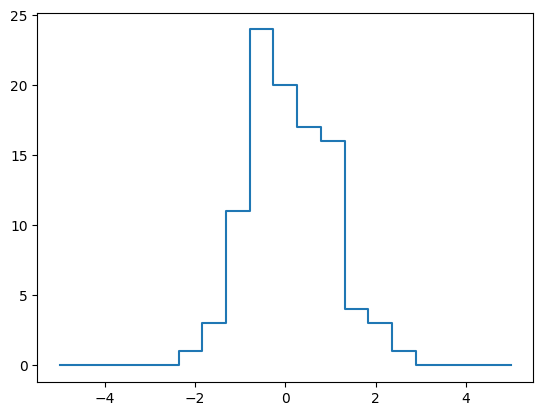

In [29]:
# 100개의 정규분포 자료
x = rng.normal(size=100)

# 20개 구간으로 나누기
bins = np.linspace(-5, 5, 20)
counts = np.zeros_like(bins)

# 각 자료가 속한 구간 찾기
i = np.searchsorted(bins, x)

# 각 구간에 1씩 더하기
np.add.at(counts, i, 1)

# Visualization of Result
plt.plot(bins, counts, drawstyle='steps')